In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

model = ChatOpenAI(model="gpt-5-mini")

In [3]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [6]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

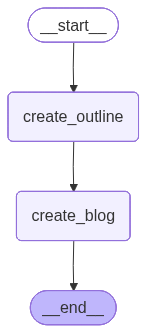

In [12]:
workflow

In [11]:
workflow.get_graph().print_ascii()

  +-----------+    
  | __start__ |    
  +-----------+    
         *         
         *         
         *         
+----------------+ 
| create_outline | 
+----------------+ 
         *         
         *         
         *         
  +-------------+  
  | create_blog |  
  +-------------+  
         *         
         *         
         *         
    +---------+    
    | __end__ |    
    +---------+    


In [7]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Below is a detailed, ready-to-use blog outline on “Rise of AI in India.” It includes suggested headings/subheadings, key points to cover in each section, data/quote prompts, case studies, visuals, SEO elements, and estimated word counts to help you write the post or brief a writer.\n\nTitle ideas (pick one or iterate)\n- Rise of AI in India: How Artificial Intelligence is Transforming the Nation\n- India’s AI Revolution: Opportunities, Challenges, and the Road Ahead\n- From Labs to Lives: The Rise of Artificial Intelligence Across India\n\nMeta description (150–160 chars)\nHow AI is reshaping India — government policy, startups, key sectors (health, agriculture, finance), talent, challenges, and what’s next for AI adoption.\n\nEstimated total length: 1,800–2,500 words (adjust per audience). Suggested section lengths included below.\n\nOutline\n\n1. Hook / Opening (150–200 words)\n- Quick, compelling anecdote or statistic (e.g., an AI-driven 

In [8]:
print(final_state['title'])

Rise of AI in India


In [9]:
print(final_state['outline'])

Below is a detailed, ready-to-use blog outline on “Rise of AI in India.” It includes suggested headings/subheadings, key points to cover in each section, data/quote prompts, case studies, visuals, SEO elements, and estimated word counts to help you write the post or brief a writer.

Title ideas (pick one or iterate)
- Rise of AI in India: How Artificial Intelligence is Transforming the Nation
- India’s AI Revolution: Opportunities, Challenges, and the Road Ahead
- From Labs to Lives: The Rise of Artificial Intelligence Across India

Meta description (150–160 chars)
How AI is reshaping India — government policy, startups, key sectors (health, agriculture, finance), talent, challenges, and what’s next for AI adoption.

Estimated total length: 1,800–2,500 words (adjust per audience). Suggested section lengths included below.

Outline

1. Hook / Opening (150–200 words)
- Quick, compelling anecdote or statistic (e.g., an AI-driven healthcare diagnosis or farm yield improvement).
- One-sente

In [10]:
print(final_state['content'])

Title: Rise of AI in India: How Artificial Intelligence is Transforming the Nation

Meta description:
How AI is reshaping India — government policy, startups, key sectors (health, agriculture, finance), talent, challenges, and what’s next for AI adoption.

1. Hook / Opening (about 170 words)
On a humid morning in a tier-2 city, a clinic without a radiologist can now run a breast-screening test and flag suspicious scans for remote specialists within minutes. In another district, a smallholder farmer receives a text alert predicting a pest outbreak and tailored advice on an inexpensive treatment — preventing crop loss and protecting income. These are not sci‑fi vignettes; they are early examples of artificial intelligence (AI) moving from research labs and boardrooms into everyday Indian life.

AI in India is no longer only an R&D headline: it’s being deployed to improve diagnostics, optimize supply chains, personalize finance, and extend government services. The stakes are high — AI can